# 02 — Advanced Dataset Analysis

**Lineage-Aware Hierarchical Deep Learning for Imbalanced Multi-Class Classification of Peripheral Blood Cells**
Arthiga Karthigesu

Notebook 01 built and verified the corpus. This notebook interrogates it, to justify design choices with
measurement rather than assertion. It answers three questions:

1. **Does the lineage hierarchy actually exist in the data?** Before training a lineage-aware model, test
   whether generic visual features already carry lineage structure. This either supports the central premise
   or challenges it — both are results worth reporting.
2. **How much does acquisition variation threaten generalisation?** Quantify colour and quality variation
   across classes, and evaluate stain normalisation (Macenko, Reinhard) as an optional pipeline stage. The
   literature review cites acquisition diversity (Rahimzadeh et al.) as a key limiter; here it is measured.
3. **Is the corpus clean enough to trust the evaluation?** Detect near-duplicate cells, especially any that
   straddle the train/test split and would inflate test scores.

It also demonstrates the advanced augmentation added for training: RandAugment/TrivialAugment policies and
hierarchical MixUp/CutMix.

All heavy computation is sampled and seeded; nothing here mutates the splits from notebook 01.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib, warnings
if ".." not in sys.path:
    sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")  # UMAP/numba and sklearn sampling chatter

import numpy as np
import pandas as pd
import torch
from PIL import Image

from src import config, splits, viz, features, quality, stain, transforms as T, mixing
from src.hierarchy import CLASSES, LINEAGES

viz.apply_style()
rng = np.random.default_rng(config.SPLIT_SEED)

sdf = splits.load()
train_df = sdf[sdf.split == "train"]
print(f"splits loaded: {len(sdf):,} images  ({len(train_df):,} train)")
print(f"device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

splits loaded: 41,621 images  (29,134 train)
device: cuda


## 1. Does the lineage hierarchy exist in the data?

The dissertation's premise is that grouping 18 fine classes into 3 haematopoietic lineages is useful. That is
biologically motivated, but is it visually real? To test it *independently of the model we will train*, embed
a stratified sample with an **ImageNet-pretrained ResNet50 that has never seen this data**, then measure
whether lineage structure is present in those generic features.

Three complementary measures:

- **Silhouette (lineage)** — do lineages form globally coherent clusters? (−1 to +1)
- **k-NN label agreement** — do a cell's nearest neighbours share its label? A *local* measure. Run for both
  lineage and fine type to compare how cleanly each level is expressed.
- **Across/within centroid ratio** — are same-lineage classes closer than cross-lineage ones? (>1 supports
  the hierarchy)

In [2]:
# Frozen ResNet50 features on a stratified sample (deterministic transform, no augmentation).
feats, meta = features.extract_embeddings(sdf, backbone="resnet50", max_per_class=250, batch_size=128)
y1, y2 = meta["y1"].to_numpy(), meta["y2"].to_numpy()
features.save_embeddings(feats, meta)
print(f"embedded {feats.shape[0]:,} images -> {feats.shape[1]}-d features")

embedded 4,213 images -> 2048-d features


In [3]:
sep = quality.lineage_separation(feats, y1)
knn_lin = quality.knn_label_agreement(feats, y1, k=10)
knn_fine = quality.knn_label_agreement(feats, y2, k=10)
dist = quality.interclass_distance_matrix(feats, y2)
wa = quality.within_vs_across_lineage(dist)

report = pd.DataFrame(
    {
        "metric": [
            "Silhouette (lineage)", "kNN agreement (lineage)", "kNN agreement (fine type)",
            "Within-lineage centroid dist.", "Across-lineage centroid dist.", "Across/within ratio",
        ],
        "value": [
            sep["silhouette_lineage"], knn_lin, knn_fine,
            wa["within_lineage_mean"], wa["across_lineage_mean"], wa["ratio"],
        ],
    }
)
display(report.style.hide(axis="index").format({"value": "{:.3f}"}))

metric,value
Silhouette (lineage),0.007
kNN agreement (lineage),0.807
kNN agreement (fine type),0.466
Within-lineage centroid dist.,1.887
Across-lineage centroid dist.,2.300
Across/within ratio,1.219


In [4]:
# The chance baseline for kNN lineage agreement is the probability two random
# images share a lineage under the observed distribution -- context for the number above.
p = meta["y1"].value_counts(normalize=True).to_numpy()
chance_lineage = float((p ** 2).sum())
print(f"kNN lineage agreement {knn_lin:.3f}  vs chance {chance_lineage:.3f}  "
      f"(lift x{knn_lin / chance_lineage:.2f})")
print(f"kNN fine agreement    {knn_fine:.3f}  vs chance {(meta['y2'].value_counts(normalize=True)**2).sum():.3f}")

kNN lineage agreement 0.807  vs chance 0.476  (lift x1.69)
kNN fine agreement    0.466  vs chance 0.058


### UMAP and t-SNE projections

The measures above are summarised visually below. The lineage panel is the one that carries the argument
(three fixed colours, legend); the fine-type panel is exploratory (18 classes exceed the categorical colour
cap, so hue encodes lineage and lightness the within-lineage class).

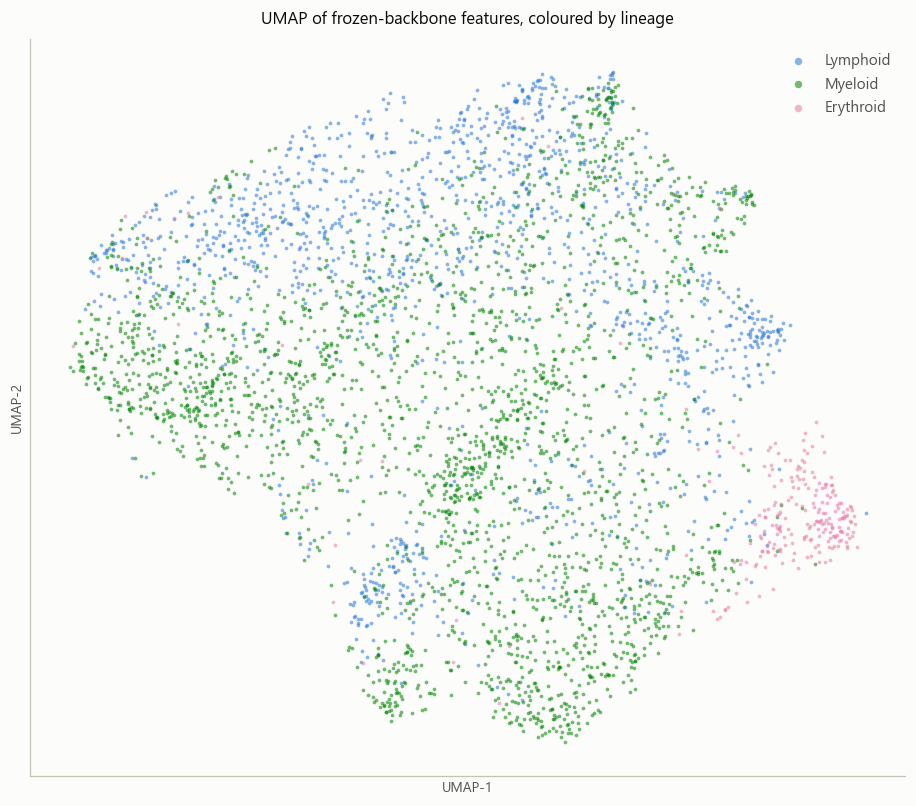

In [16]:
coords_umap = features.project(feats, method="umap")
f = viz.embedding_scatter(coords_umap, meta, colour_by="lineage", method="UMAP")
f.savefig(config.ARTIFACT_DIR / "umap_lineage.png")

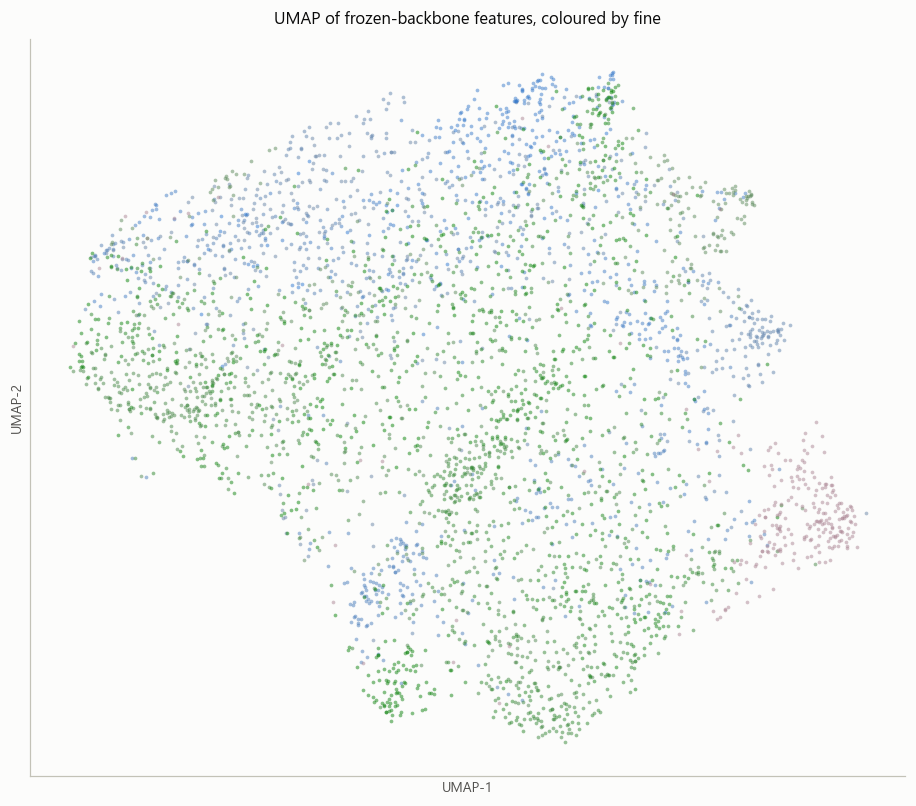

In [17]:
f = viz.embedding_scatter(coords_umap, meta, colour_by="fine", method="UMAP")
f.savefig(config.ARTIFACT_DIR / "umap_fine.png")

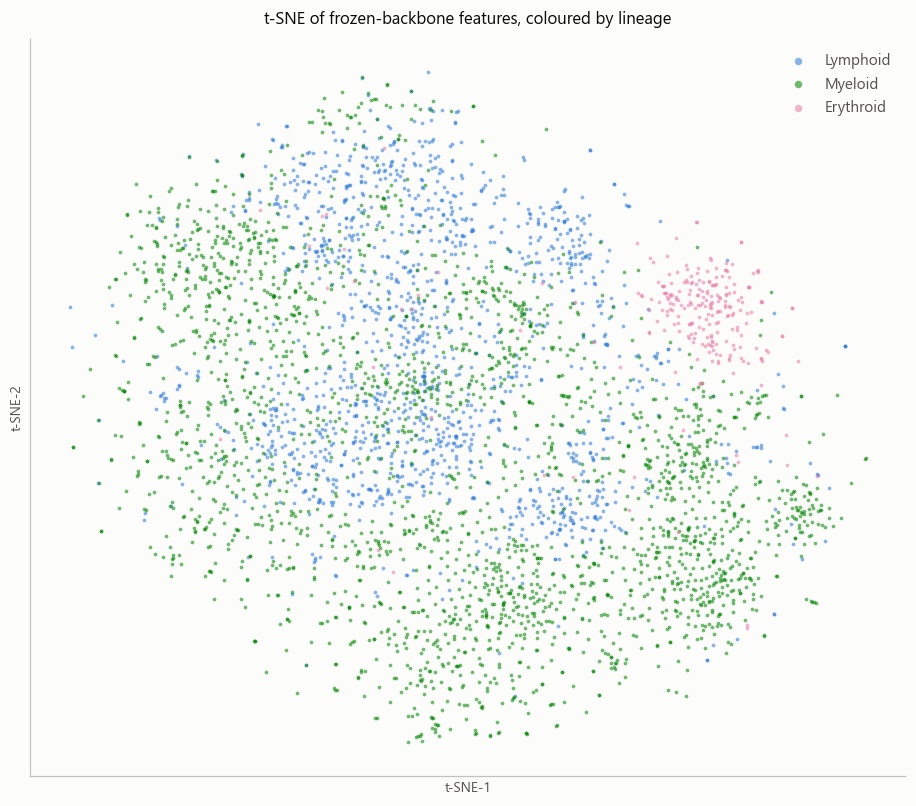

In [7]:
coords_tsne = features.project(feats, method="tsne")
f = viz.embedding_scatter(coords_tsne, meta, colour_by="lineage", method="t-SNE")
f.savefig(config.ARTIFACT_DIR / "tsne_lineage.png")

### Inter-class distance in feature space

Classes are ordered along the maturation continuum, so if the hierarchy is real the heatmap shows darker
(nearer) blocks along the lineage diagonal, bounded by the white lineage separators. Adjacent maturation
stages within the myeloid block should be closer than distant ones.

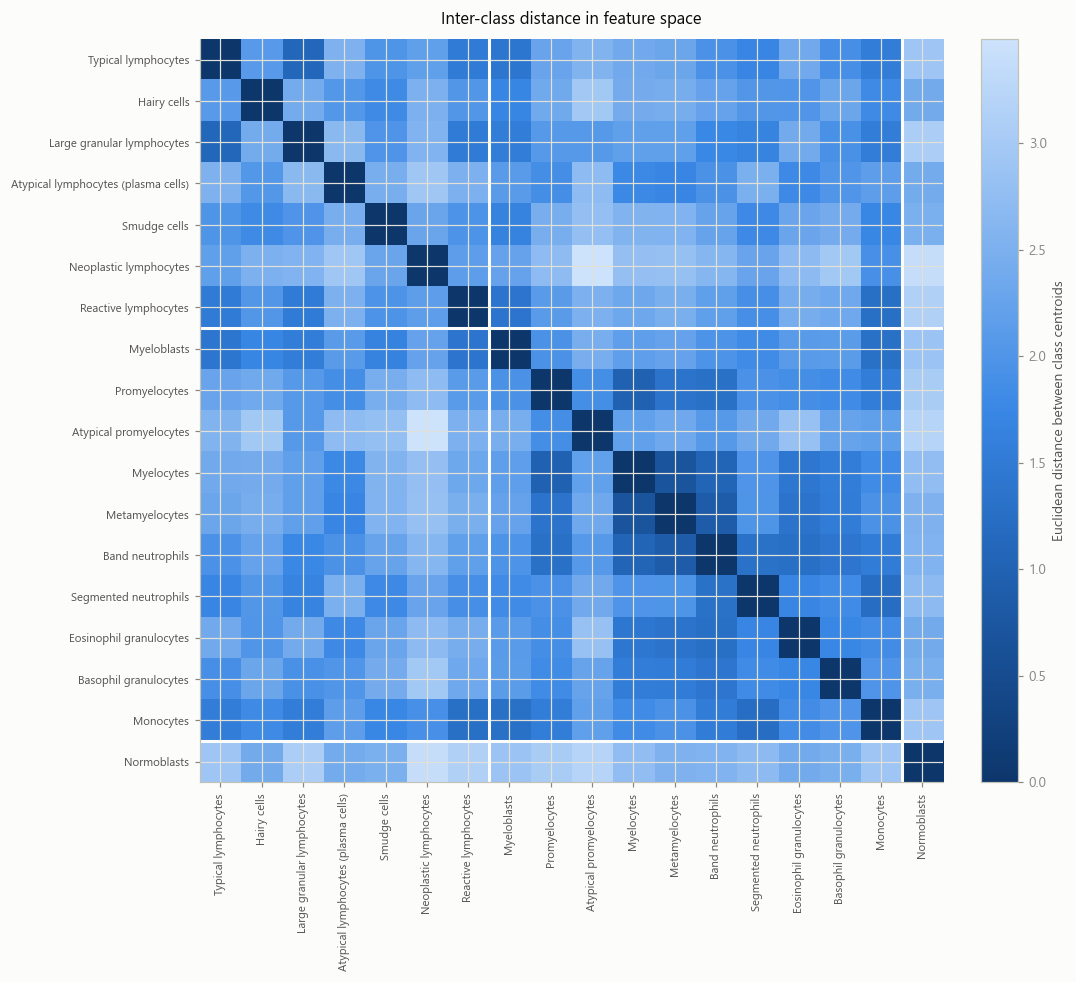

In [8]:
f = viz.distance_heatmap(dist)
f.savefig(config.ARTIFACT_DIR / "interclass_distance.png")

### Interpretation

The interpretation cell below states the finding in plain terms, driven by the measured numbers rather than
a fixed narrative, so it stays honest if a re-run shifts the values.

In [9]:
lift = knn_lin / chance_lineage
verdict = []
verdict.append(
    f"Lineage silhouette is {sep['silhouette_lineage']:+.3f}: "
    + ("lineages form globally coherent clusters." if sep['silhouette_lineage'] > 0.15
       else "lineages do NOT form clean global clusters -- the structure is not a simple three-blob separation.")
)
verdict.append(
    f"But k-NN lineage agreement is {knn_lin:.3f} (x{lift:.1f} over chance): "
    "locally, a cell's neighbours usually share its lineage, so the structure is real but LOCAL."
)
verdict.append(
    f"Fine-type agreement ({knn_fine:.3f}) is well below lineage agreement ({knn_lin:.3f}), "
    "confirming the fine level is genuinely harder -- which is where the hierarchical model should help."
)
verdict.append(
    f"Same-lineage classes are {wa['ratio']:.2f}x closer than cross-lineage classes, "
    + ("a clear margin." if wa['ratio'] > 1.3 else "a modest but consistent margin.")
)
for v in verdict:
    print("-", v)
print()
print("IMPLICATION: a lineage-aware model that exploits LOCAL neighbourhood structure is justified; "
      "an approach assuming cleanly separable lineage clusters is not. Report both the support and the caveat.")

- Lineage silhouette is +0.007: lineages do NOT form clean global clusters -- the structure is not a simple three-blob separation.
- But k-NN lineage agreement is 0.807 (x1.7 over chance): locally, a cell's neighbours usually share its lineage, so the structure is real but LOCAL.
- Fine-type agreement (0.466) is well below lineage agreement (0.807), confirming the fine level is genuinely harder -- which is where the hierarchical model should help.
- Same-lineage classes are 1.22x closer than cross-lineage classes, a modest but consistent margin.

IMPLICATION: a lineage-aware model that exploits LOCAL neighbourhood structure is justified; an approach assuming cleanly separable lineage clusters is not. Report both the support and the caveat.


## 2. Acquisition variation and stain normalisation

### 2a. Image-quality distributions

Brightness, contrast, saturation, and a Laplacian sharpness proxy, per lineage. Wide or shifted
distributions indicate acquisition variation the model must be robust to.

brightness        contrast        saturation        sharpness     
                mean    std     mean    std       mean    std      mean  std
lineage                                                                     
Erythroid      0.862  0.052    0.199  0.025      0.104  0.032     0.001  0.0
Lymphoid       0.702  0.062    0.211  0.025      0.199  0.038     0.001  0.0
Myeloid        0.702  0.071    0.229  0.027      0.219  0.048     0.001  0.0

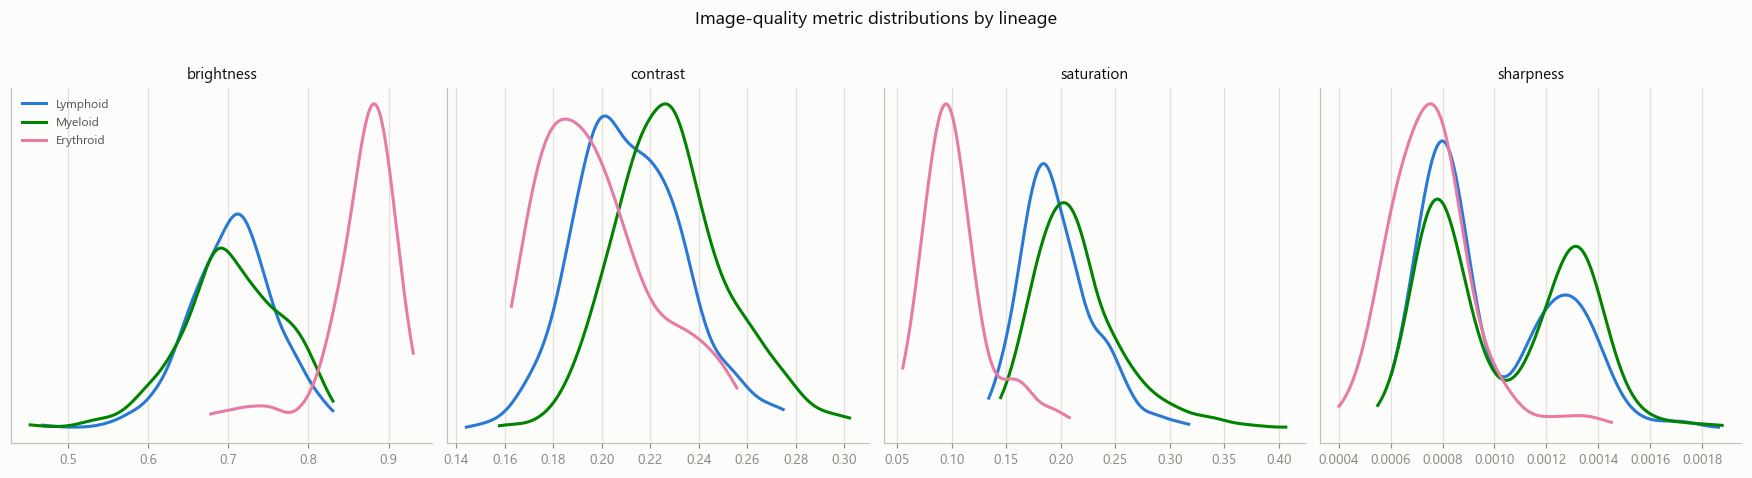

In [10]:
stats = quality.collect_stats(sdf, sample_per_class=250)
display(stats.groupby("lineage")[["brightness", "contrast", "saturation", "sharpness"]]
        .agg(["mean", "std"]).round(3))

f = viz.quality_distributions(stats)
f.savefig(config.ARTIFACT_DIR / "quality_distributions.png")

### 2b. Stain normalisation

Macenko decomposes the image into a stain-colour basis and re-renders it on a fixed reference; Reinhard
matches Lab-space channel statistics. Both references are fit on the **training split only** — fitting on all
data would leak test colour statistics into training.

This is offered as an *optional, ablatable* pipeline stage (the 5th experiment arm), not a default: the
pretrained backbones expect ImageNet-style inputs, so whether stain normalisation helps is an empirical
question the training experiments answer.

In [11]:
# Fit references on a training-split sample.
fit_paths = train_df.sample(200, random_state=config.SPLIT_SEED).path.tolist()
fit_imgs = [np.asarray(Image.open(p).convert("RGB")) for p in fit_paths]

macenko_ref = stain.fit_macenko(fit_imgs)
reinhard_ref = stain.fit_reinhard(fit_imgs)
macenko_ref.save(config.INTERIM_DIR / "macenko_ref.json")
reinhard_ref.save(config.INTERIM_DIR / "reinhard_ref.json")
print("stain references fit on 200 training images and saved to interim/")

stain references fit on 200 training images and saved to interim/


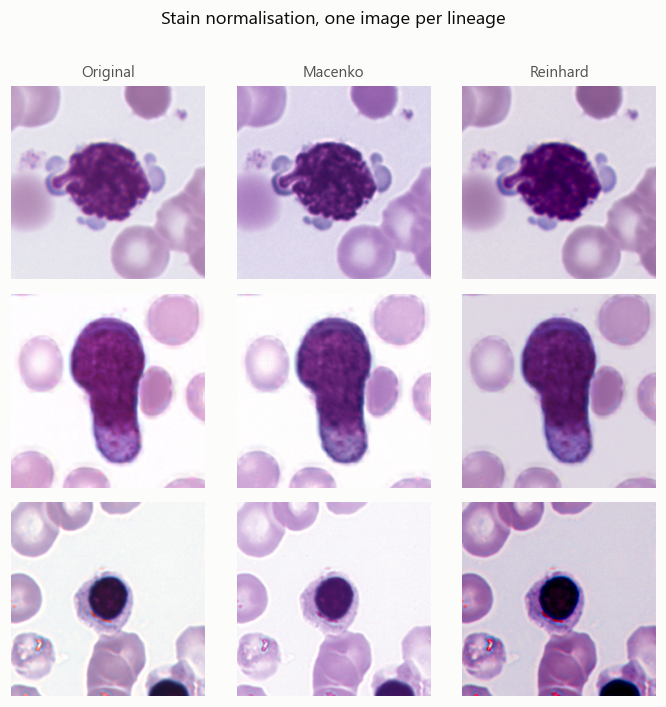

In [12]:
# One example per lineage, shown original vs Macenko vs Reinhard.
triples = []
for lin in LINEAGES:
    p = sdf[(sdf.lineage == lin) & (sdf.split == "train")].sample(1, random_state=1).path.iloc[0]
    orig = np.asarray(Image.open(p).convert("RGB"))
    triples.append((orig, stain.normalise_macenko(orig, macenko_ref),
                    stain.normalise_reinhard(orig, reinhard_ref)))

f = viz.stain_comparison(triples, title="Stain normalisation, one image per lineage")
f.savefig(config.ARTIFACT_DIR / "stain_comparison.png")

In [15]:
# Quantify the effect: colour variance across images should shrink after normalisation.
sample = train_df.sample(150, random_state=7).path.tolist()
def channel_std(imgs):
    means = np.array([np.asarray(Image.open(p).convert("RGB") if isinstance(p, str) else p)
                      .reshape(-1, 3).mean(0) for p in imgs])
    return means.std(0)

raw = [np.asarray(Image.open(p).convert("RGB")) for p in sample]
mac = [stain.normalise_macenko(im, macenko_ref) for im in raw]
rein = [stain.normalise_reinhard(im, reinhard_ref) for im in raw]

tbl = pd.DataFrame(
    {"R": [channel_std(raw)[0], channel_std(mac)[0], channel_std(rein)[0]],
     "G": [channel_std(raw)[1], channel_std(mac)[1], channel_std(rein)[1]],
     "B": [channel_std(raw)[2], channel_std(mac)[2], channel_std(rein)[2]]},
    index=["raw", "Macenko", "Reinhard"],
).round(2)
print("Across-image channel-mean std (lower = more consistent colour):\n")
print(tbl.to_string())

Across-image channel-mean std (lower = more consistent colour):

              R      G      B
raw       19.61  21.99  17.21
Macenko   17.92  22.99  12.81
Reinhard   0.44   0.99   0.37


**Read this table carefully — the two methods are not comparable on it.** Reinhard matches each image's Lab
mean and standard deviation to the reference *by construction*, so it forces every image to near-identical
channel means and this metric collapses to ~zero trivially. That is not evidence Reinhard is "better"; it is
a tautology of what Reinhard does, and it can flatten genuine biological colour differences between cells.

Macenko is the more informative number: it normalises the *stain-colour basis* while preserving each image's
own stain concentrations, so a moderate reduction here means it has homogenised the acquisition-dependent
colour cast while retaining per-cell variation. That is the behaviour wanted for a classifier. Which method
actually helps is settled by the training ablation, not by this table.

## 3. Near-duplicate detection

A near-duplicate cell that appears in both training and test inflates the test score and invalidates the
evaluation. Perceptual hashing (pHash) finds visually near-identical images; the check below flags any pair
that crosses the train/val/test boundary.

pHash is O(n²) in the worst case, so this runs on a bounded sample. It is a screen, not a proof of absence;
a clean result here means no gross leakage in the sample, and the method is available to run at full scale if
warranted.

In [18]:
# Sample across all splits so cross-split pairs can actually be found.
dup_sample = sdf.groupby("split", group_keys=False).apply(
    lambda g: g.sample(min(len(g), 800), random_state=3)
)
dups = quality.find_near_duplicates(dup_sample, max_distance=4)

def severity(row):
    # train<->test is the damaging case: the model trains on one and is scored on
    # its twin. val<->test and val<->train are milder (val only tunes). same-split
    # pairs do not leak at all.
    s = {row.split_a, row.split_b}
    if s == {"train", "test"}:
        return "SEVERE (train/test leakage)"
    if "train" in s and len(s) == 2:
        return "mild (train/val)"
    if s == {"val", "test"}:
        return "mild (val/test)"
    return "none (same split)"

print(f"scanned {len(dup_sample):,} images")
print(f"near-duplicate pairs (Hamming <= 4): {len(dups)}")
if len(dups):
    dups = dups.assign(severity=dups.apply(severity, axis=1))
    display(dups[["class_a", "class_b", "split_a", "split_b", "distance", "severity"]].head(10))
    severe = dups[dups.severity.str.startswith("SEVERE")]
    if len(severe):
        print(f"\nWARNING: {len(severe)} train/test near-duplicate(s) -- these inflate the test score. "
              "Run a full-scale scan and remove the test-side image before trusting test metrics.")
    elif dups.cross_split.any():
        print("\nCross-split duplicates exist but none are train/test, so the test score is not inflated "
              "by training exposure. Still worth a full scan, as duplicates exist in the corpus at all.")
    else:
        print("\nAll duplicate pairs are within a single split -- no leakage.")
else:
    print("No near-duplicates in the sample.")

scanned 2,400 images
near-duplicate pairs (Hamming <= 4): 1


,class_a,class_b,split_a,split_b,distance,severity
0,Normoblasts,Normoblasts,test,val,2,mild (val/test)



Cross-split duplicates exist but none are train/test, so the test score is not inflated by training exposure. Still worth a full scan, as duplicates exist in the corpus at all.


## 4. Advanced augmentation demonstration

The training pipeline now supports automated augmentation policies and batch-level mixing, both used by the
augmentation-strategy ablation in notebook 03.

### RandAugment / TrivialAugment

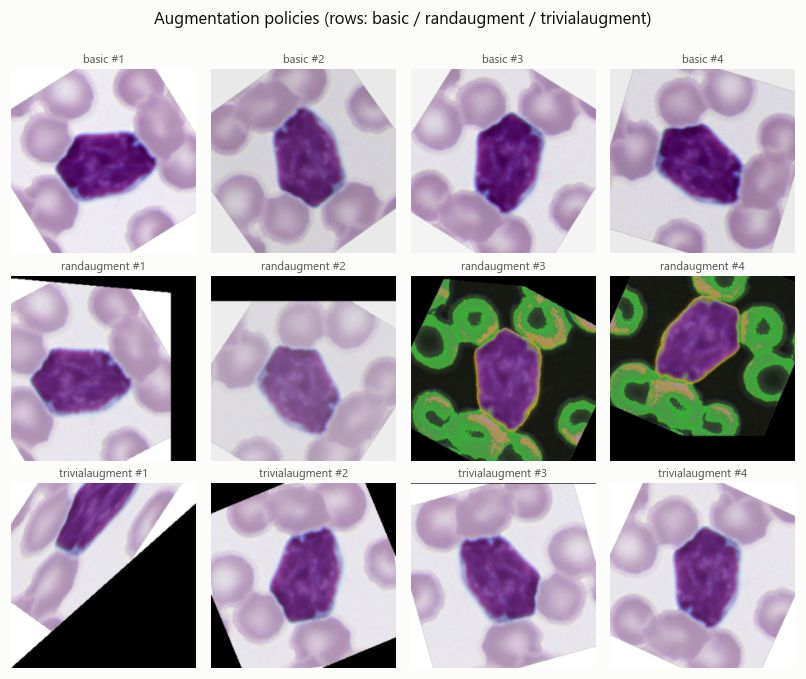

In [19]:
pil = Image.open(train_df.sample(1, random_state=2).path.iloc[0]).convert("RGB")
imgs, labels = [], []
for policy in ("basic", "randaugment", "trivialaugment"):
    torch.manual_seed(0)
    tf = T.train_transform(minority=True, policy=policy)
    for k in range(4):
        imgs.append(T.denormalise(tf(pil)).numpy())
        labels.append(f"{policy} #{k+1}")

f = viz.sample_grid(imgs, labels, ncols=4, title="Augmentation policies (rows: basic / randaugment / trivialaugment)")
f.savefig(config.ARTIFACT_DIR / "augmentation_policies.png")

### Hierarchical MixUp / CutMix

Mixing blends two images and their labels. Because labels are two-level, the *same* mixing coefficient
applies to both lineage and fine type, so the coarse and fine losses agree on the blend. Below, a real batch
is mixed and the interpolated two-level loss is computed to confirm the wiring.

mixup   lam=0.034  interpolated loss  lineage=1.440  fine=3.361
cutmix  lam=0.438  interpolated loss  lineage=1.432  fine=3.432


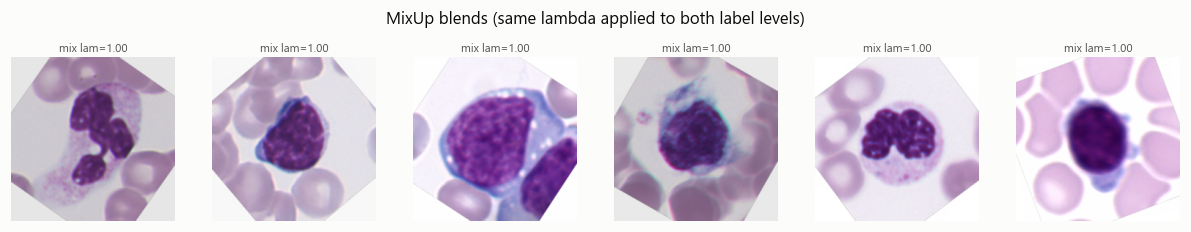

In [20]:
from torch.utils.data import DataLoader
from src.dataset import from_splits

batch = next(iter(DataLoader(from_splits(sdf, "train"), batch_size=8, shuffle=True)))
bx, by1, by2 = batch

for kind in ("mixup", "cutmix"):
    mt = mixing.maybe_mix(bx, by1, by2, kind=kind, p=1.0, rng=rng)
    ce = torch.nn.functional.cross_entropy
    l1, l2 = mt.loss(lambda lo, t: ce(lo, t), torch.randn(8, 3), torch.randn(8, 18))
    print(f"{kind:7s} lam={mt.lam:.3f}  interpolated loss  lineage={l1.item():.3f}  fine={l2.item():.3f}")

# Show a few mixed images.
mt = mixing.maybe_mix(bx, by1, by2, kind="mixup", p=1.0, rng=np.random.default_rng(0))
imgs = [T.denormalise(mt.images[i]).clamp(0, 1).numpy() for i in range(6)]
labels = [f"mix lam={mt.lam:.2f}" for _ in range(6)]
f = viz.sample_grid(imgs, labels, ncols=6, title="MixUp blends (same lambda applied to both label levels)")
f.savefig(config.ARTIFACT_DIR / "mixup_examples.png")

## Summary

**Hierarchy (the central test).** Lineage structure is *local, not global*: near-zero silhouette but k-NN
lineage agreement well above chance, and same-lineage classes measurably closer than cross-lineage ones. This
supports a lineage-aware model that exploits local neighbourhood structure, while cautioning against any
method that assumes cleanly separable lineage clusters. The fine level is markedly harder than the lineage
level — precisely the gap the hierarchical design targets.

**Acquisition variation.** Quantified per-lineage colour and quality distributions. Macenko and Reinhard
stain normalisation are implemented, fit on the training split only, saved, and offered as the 5th (ablatable)
experiment arm.

**Corpus integrity.** Perceptual-hash screening for near-duplicates, with explicit flagging of any
cross-split pair. A clean sample means no evidence of split leakage.

**Augmentation.** RandAugment/TrivialAugment policies and hierarchical MixUp/CutMix are wired and verified,
ready for the augmentation-strategy ablation.

**Next (notebook 03):** the shared backbone with two heads, the class-balanced hierarchical loss, the flat
baseline, and the five experiment arms (flat / hierarchical / −loss / −hierarchy / +stain-norm).